In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Baseline models
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree         import DecisionTreeClassifier
from sklearn.ensemble     import RandomForestClassifier
from xgboost              import XGBClassifier
from lightgbm             import LGBMClassifier

## 1. Label Map

In [2]:
LABEL_MAP = {
    0: "Drought",
    1: "Earthquake",
    2: "Epidemic",
    3: "Extreme Temp",
    4: "Flood",
    5: "Landslide",
    6: "Storm",
    7: "Wildfire",
}
TARGET_NAMES = [LABEL_MAP[i] for i in sorted(LABEL_MAP)]

## 2. Load CLeaned

In [3]:
data = pd.read_excel('../data/cleaned/cleaned_disaster_dataset.xlsx')
data.head()

,event_duration_log_norm,magnitude_missing,subregion_Australia and New Zealand,subregion_Central Asia,subregion_Eastern Asia,subregion_Eastern Europe,subregion_Latin America and the Caribbean,subregion_Melanesia,subregion_Micronesia,subregion_Northern Africa,...,country_Viet Nam,country_Wallis and Futuna Islands,country_Yemen,country_Yemen Arab Republic,country_Yugoslavia,country_Zambia,country_Zimbabwe,total_deaths_normalized,magnitude_scaled,disaster_type_encoded
0,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.575230,0.329509,6
1,0.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0.377358,0.000000,4
2,0.0,1,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0.227058,0.000000,2
3,0.0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.327216,0.117902,1
4,0.0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0.928246,0.000000,0


## 3. Define X Y

In [4]:
X = data.drop("disaster_type_encoded", axis=1).copy()
y = data["disaster_type_encoded"]

# LightGBM cannot fit feature names with punctuation or non-ASCII symbols.
def make_model_safe_columns(columns):
    safe_columns = (
        pd.Series(columns, dtype="string")
        .str.replace(r"[^A-Za-z0-9_]+", "_", regex=True)
        .str.strip("_")
    )
    safe_columns = safe_columns.mask(safe_columns == "", "feature")

    counts = {}
    unique_columns = []
    for column in safe_columns:
        base = str(column)
        count = counts.get(base, 0)
        unique_columns.append(base if count == 0 else f"{base}_{count}")
        counts[base] = count + 1
    return unique_columns

original_feature_names = X.columns.tolist()
X.columns = make_model_safe_columns(original_feature_names)
renamed_features = sum(
    old != new for old, new in zip(original_feature_names, X.columns)
)
print(f"Renamed {renamed_features} feature columns for model compatibility.")

for code, name in LABEL_MAP.items():
    n = (y == code).sum()
    print(f"  {code} {name:<20} {n:>5}  ({n/len(y)*100:.1f}%)")

Renamed 93 feature columns for model compatibility.
  0 Drought                803  (4.6%)
  1 Earthquake            1651  (9.4%)
  2 Epidemic              1622  (9.3%)
  3 Extreme Temp           730  (4.2%)
  4 Flood                 6183  (35.4%)
  5 Landslide              918  (5.3%)
  6 Storm                 5053  (28.9%)
  7 Wildfire               514  (2.9%)


In [5]:
X.columns = X.columns.str.replace(r'[\[\]\{\}\:\,"]', '_', regex=True)

In [6]:
print(data.columns.tolist())

['event_duration_log_norm', 'magnitude_missing', 'subregion_Australia and New Zealand', 'subregion_Central Asia', 'subregion_Eastern Asia', 'subregion_Eastern Europe', 'subregion_Latin America and the Caribbean', 'subregion_Melanesia', 'subregion_Micronesia', 'subregion_Northern Africa', 'subregion_Northern America', 'subregion_Northern Europe', 'subregion_Polynesia', 'subregion_South-eastern Asia', 'subregion_Southern Asia', 'subregion_Southern Europe', 'subregion_Sub-Saharan Africa', 'subregion_Western Asia', 'subregion_Western Europe', 'region_Africa', 'region_Americas', 'region_Asia', 'region_Europe', 'region_Oceania', 'magnitude_scale_Km2', 'magnitude_scale_Kph', 'magnitude_scale_Moment Magnitude', 'magnitude_scale_Morbidity rate', 'magnitude_scale_Vaccinated', 'magnitude_scale_°C', 'country_Afghanistan', 'country_Albania', 'country_Algeria', 'country_American Samoa', 'country_Angola', 'country_Anguilla', 'country_Antigua and Barbuda', 'country_Argentina', 'country_Armenia', 'coun

## 4. Split Train 80/20 Test
`stratify=y` ensures every class lands at the same proportion in both splits. 

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

# Verify stratification held
print("\nClass proportions — train vs test (should match):")
for code, name in LABEL_MAP.items():
    tr = (y_train == code).sum() / len(y_train) * 100
    te = (y_test  == code).sum() / len(y_test)  * 100
    print(f"  {name:<20}  train {tr:.1f}%   test {te:.1f}%")

Train size: (13979, 262)
Test size: (3495, 262)

Class proportions — train vs test (should match):
  Drought               train 4.6%   test 4.6%
  Earthquake            train 9.4%   test 9.4%
  Epidemic              train 9.3%   test 9.3%
  Extreme Temp          train 4.2%   test 4.2%
  Flood                 train 35.4%   test 35.4%
  Landslide             train 5.3%   test 5.3%
  Storm                 train 28.9%   test 28.9%
  Wildfire              train 2.9%   test 2.9%


## 5. Cross-Validation Setup

`StratifiedKFold` preserves class proportions in every fold — essential with a 12× imbalance.  
CV is run **on the training set only**; the test set remains unseen.

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
SCORING = [
    "accuracy",
    "f1_macro", "f1_weighted",
    "precision_macro", "precision_weighted",
    "recall_macro", "recall_weighted",
]

## 8. Model

6 models from simplest to most powerful:

| Model | Type | Notes |
|-------|------|-------|
|SVM (RBF) | Radial Basis Function | Best at non-linear boundaries; slower on large data |
| Logistic Regression | Linear | Fast, interpretable |
| Decision Tree | Non-linear | Single tree, prone to overfit |
| Random Forest | Ensemble (bagging) | Strong baseline |
| XGBoost | Ensemble (boosting) | Usually top performer | -->
| LightGBM | Ensemble (boosting) | Faster than XGBoost on large data |

## 8.1 Baseline Models without any imbalance-specific treatment

In [14]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM"                : SVC(random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(random_state=42),
    "Random Forest"      : RandomForestClassifier(random_state=42),
    "XGBoost"            : XGBClassifier(random_state=42),
    "LightGBM"           : LGBMClassifier(random_state=42, force_row_wise='true')
}

In [15]:
## Test Set
test_summary = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test_summary.append({
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_test, y_pred),
        "F1 Macro"   : f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision Macro"  : precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Precision Weighted"  : precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "Recall Macro"     : recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Recall Weighted"     : recall_score(y_test, y_pred, average="weighted", zero_division=0)
    })

test_df = pd.DataFrame(test_summary).set_index("Model")
test_df.sort_values("F1 Macro", ascending=False).round(4)

[LightGBM] [Info] Total Bins 1052
[LightGBM] [Info] Number of data points in the train set: 13979, number of used features: 162
[LightGBM] [Info] Start training from score -3.079167
[LightGBM] [Info] Start training from score -2.359167
[LightGBM] [Info] Start training from score -2.376732
[LightGBM] [Info] Start training from score -3.175410
[LightGBM] [Info] Start training from score -1.038977
[LightGBM] [Info] Start training from score -2.946802
[LightGBM] [Info] Start training from score -1.240817
[LightGBM] [Info] Start training from score -3.526718
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Precision Weighted,Recall Macro,Recall Weighted
Model,,,,,,,
LightGBM,0.9062,0.8090,0.8980,0.8540,0.8982,0.7832,0.9062
Random Forest,0.8941,0.7992,0.8894,0.8216,0.8873,0.7832,0.8941
XGBoost,0.9056,0.7970,0.8947,0.8557,0.8968,0.7696,0.9056
Decision Tree,0.8867,0.7951,0.8844,0.8016,0.8826,0.7895,0.8867
Logistic Regression,0.8887,0.7308,0.8655,0.8525,0.8772,0.7050,0.8887
SVM,0.8858,0.6783,0.8483,0.8562,0.8680,0.6723,0.8858


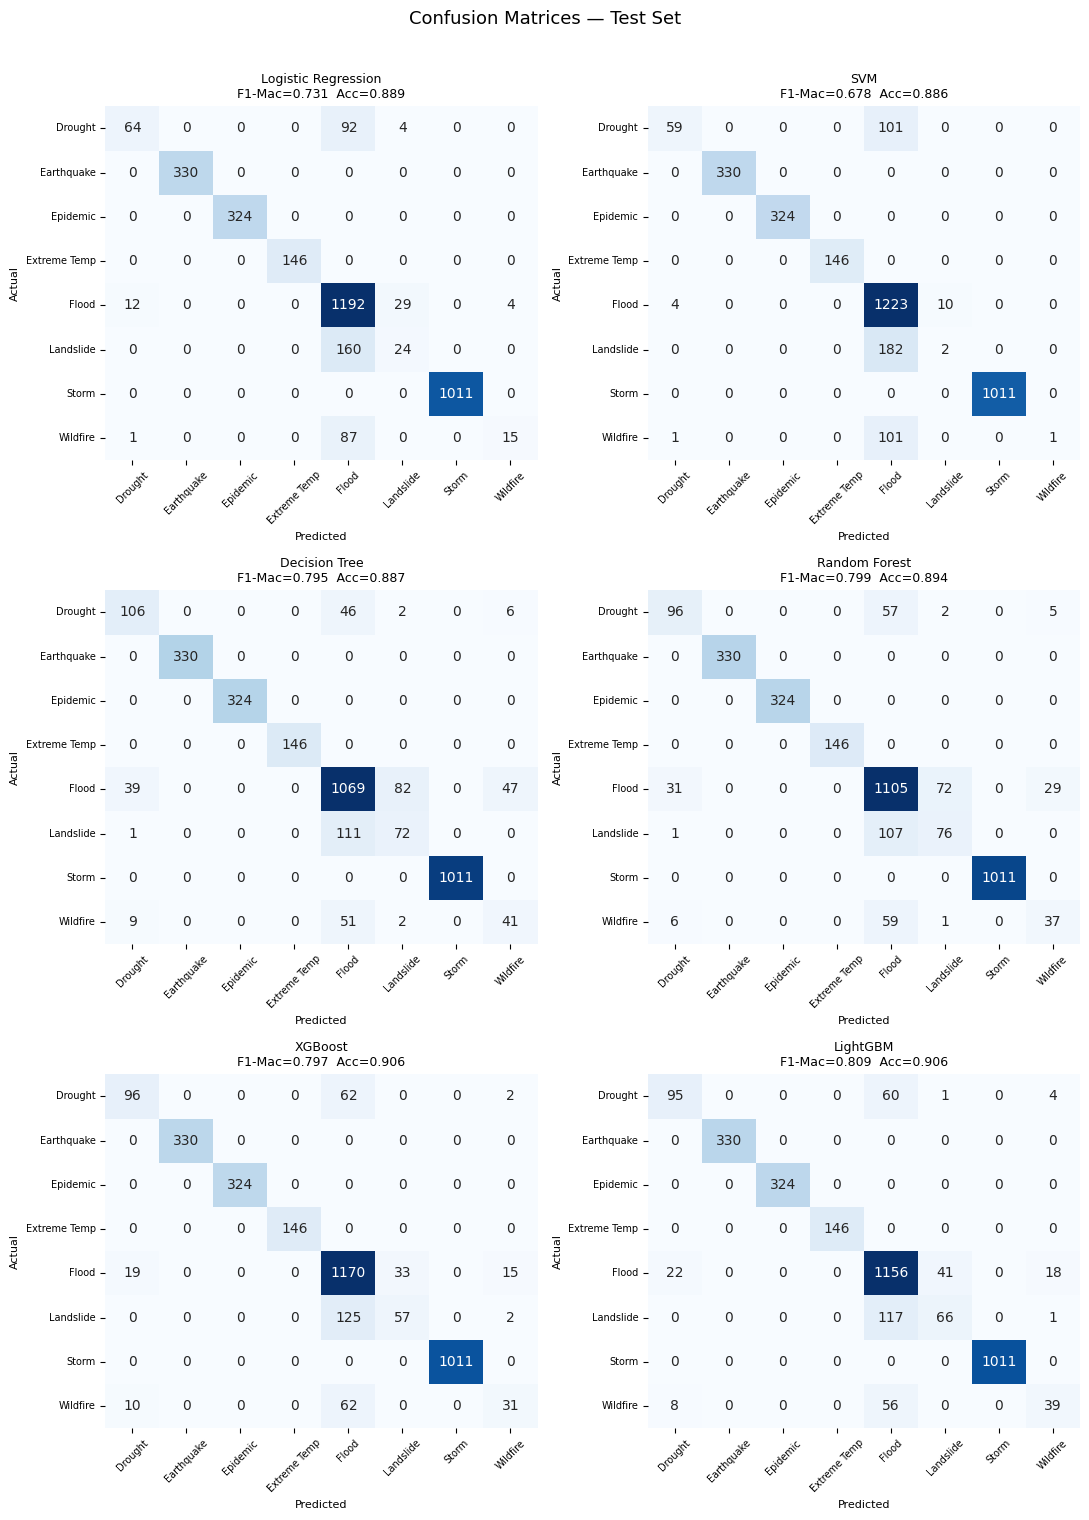

In [ ]:
n_models = len(models)             
ncols    = 2
nrows    = (n_models + ncols - 1) // ncols   # auto-compute rows

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 5))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                cmap="Blues", cbar=False)
    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nF1-Mac={f1:.3f}  Acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

# Hide unused subplots
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 8.2 Baseline Models with imbalance treatment 
**`class_weight='balanced'`**

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(
                               max_iter=1000,
                               class_weight="balanced",
                               random_state=42),
    "Decision Tree"      : DecisionTreeClassifier(
                               class_weight="balanced",
                               random_state=42),
    "Random Forest"      : RandomForestClassifier(
                               n_estimators=200,
                               class_weight="balanced",
                               random_state=42,
                               n_jobs=-1),
    "XGBoost"            : XGBClassifier(
                               n_estimators=200,
                               eval_metric="mlogloss",
                               random_state=42,
                               n_jobs=-1,
                              verbosity=0),
    "LightGBM"           : LGBMClassifier(
                               n_estimators=200,
                               class_weight="balanced",
                               random_state=42,
                               n_jobs=-1,
                               verbose=-1),
    "SVM (RBF)"          : SVC(
                               kernel="rbf",
                               class_weight="balanced",
                               random_state=42,
                               cache_size=500),

}

## 9. Cross-Validation Results (Train Set Only)

> **Why F1-Macro?**  
> Accuracy is misleading here — a model that always predicts Flood scores 35%.  
> F1-Macro averages the F1 score across all 8 classes equally, penalising 
> the model for ignoring rare classes like Wildfire (2.9%).

In [ ]:
cv_summary = []

for name, model in models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv, scoring=SCORING,
        return_train_score=False, n_jobs=-1
    )
    cv_summary.append({
        "Model"            : name,
        "Accuracy"         : scores["test_accuracy"].mean(),
        "Accuracy ±"       : scores["test_accuracy"].std(),
        "F1 Macro"         : scores["test_f1_macro"].mean(),
        "F1 Macro ±"       : scores["test_f1_macro"].std(),
        "F1 Weighted"      : scores["test_f1_weighted"].mean(),
        "F1 Weighted ±"    : scores["test_f1_weighted"].std(),
        "Precision Macro"  : scores["test_precision_macro"].mean(),
        "Precision Macro ±": scores["test_precision_macro"].std(),
        "Recall Macro"     : scores["test_recall_macro"].mean(),
        "Recall Macro ±"   : scores["test_recall_macro"].std(),
    })
    print(f"{name:<22}  "
          f"Acc={scores['test_accuracy'].mean():.4f}±{scores['test_accuracy'].std():.4f}  "
          f"F1-Mac={scores['test_f1_macro'].mean():.4f}±{scores['test_f1_macro'].std():.4f}  "
          f"F1-Wtd={scores['test_f1_weighted'].mean():.4f}±{scores['test_f1_weighted'].std():.4f}  "
          f"Prec-Mac={scores['test_precision_macro'].mean():.4f}±{scores['test_precision_macro'].std():.4f}  "
          f"Rec-Mac={scores['test_recall_macro'].mean():.4f}±{scores['test_recall_macro'].std():.4f}")

cv_df = pd.DataFrame(cv_summary).set_index("Model")
cv_df.sort_values("F1 Macro", ascending=False).round(4)

Logistic Regression     Acc=0.7762±0.0056  F1-Mac=0.7400±0.0041  F1-Wtd=0.7908±0.0061  Prec-Mac=0.7309±0.0028  Rec-Mac=0.8365±0.0065
Decision Tree           Acc=0.8658±0.0036  F1-Mac=0.7885±0.0026  F1-Wtd=0.8718±0.0022  Prec-Mac=0.7718±0.0033  Rec-Mac=0.8156±0.0033
Random Forest           Acc=0.8855±0.0051  F1-Mac=0.7971±0.0028  F1-Wtd=0.8856±0.0038  Prec-Mac=0.7950±0.0059  Rec-Mac=0.8006±0.0064
XGBoost                 Acc=0.9044±0.0033  F1-Mac=0.8080±0.0057  F1-Wtd=0.8977±0.0034  Prec-Mac=0.8434±0.0057  Rec-Mac=0.7864±0.0061
LightGBM                Acc=0.8691±0.0019  F1-Mac=0.8049±0.0029  F1-Wtd=0.8772±0.0020  Prec-Mac=0.7830±0.0027  Rec-Mac=0.8447±0.0042
SVM (RBF)               Acc=0.7775±0.0082  F1-Mac=0.7401±0.0059  F1-Wtd=0.7931±0.0089  Prec-Mac=0.7319±0.0040  Rec-Mac=0.8319±0.0040


,Accuracy,Accuracy ±,F1 Macro,F1 Macro ±,F1 Weighted,F1 Weighted ±,Precision Macro,Precision Macro ±,Recall Macro,Recall Macro ±
Model,,,,,,,,,,
XGBoost,0.9044,0.0033,0.8080,0.0057,0.8977,0.0034,0.8434,0.0057,0.7864,0.0061
LightGBM,0.8691,0.0019,0.8049,0.0029,0.8772,0.0020,0.7830,0.0027,0.8447,0.0042
Random Forest,0.8855,0.0051,0.7971,0.0028,0.8856,0.0038,0.7950,0.0059,0.8006,0.0064
Decision Tree,0.8658,0.0036,0.7885,0.0026,0.8718,0.0022,0.7718,0.0033,0.8156,0.0033
SVM (RBF),0.7775,0.0082,0.7401,0.0059,0.7931,0.0089,0.7319,0.0040,0.8319,0.0040
Logistic Regression,0.7762,0.0056,0.7400,0.0041,0.7908,0.0061,0.7309,0.0028,0.8365,0.0065


## 10. Test Set Evaluation (Held-Out 20%)

Each model is refit on the full training set, then evaluated once on the test set.

In [ ]:
test_summary = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    test_summary.append({
        "Model"      : name,
        "Accuracy"   : accuracy_score(y_test, y_pred),
        "F1 Macro"   : f1_score(y_test, y_pred, average="macro"),
        "F1 Weighted": f1_score(y_test, y_pred, average="weighted"),
        "Precision"  : precision_score(y_test, y_pred, average="macro"),
        "Recall"     : recall_score(y_test, y_pred, average="macro")
    })

test_df = pd.DataFrame(test_summary).set_index("Model")
test_df.sort_values("F1 Macro", ascending=False).round(4)


,Accuracy,F1 Macro,F1 Weighted,Precision,Recall
Model,,,,,
XGBoost,0.9041,0.8046,0.8966,0.8417,0.7824
LightGBM,0.8627,0.7992,0.8728,0.7769,0.8449
Random Forest,0.8764,0.7863,0.8776,0.7821,0.7915
Decision Tree,0.8615,0.7816,0.8678,0.7667,0.8044
SVM (RBF),0.7740,0.7356,0.7905,0.7279,0.8293
Logistic Regression,0.7717,0.7345,0.7873,0.7267,0.8304


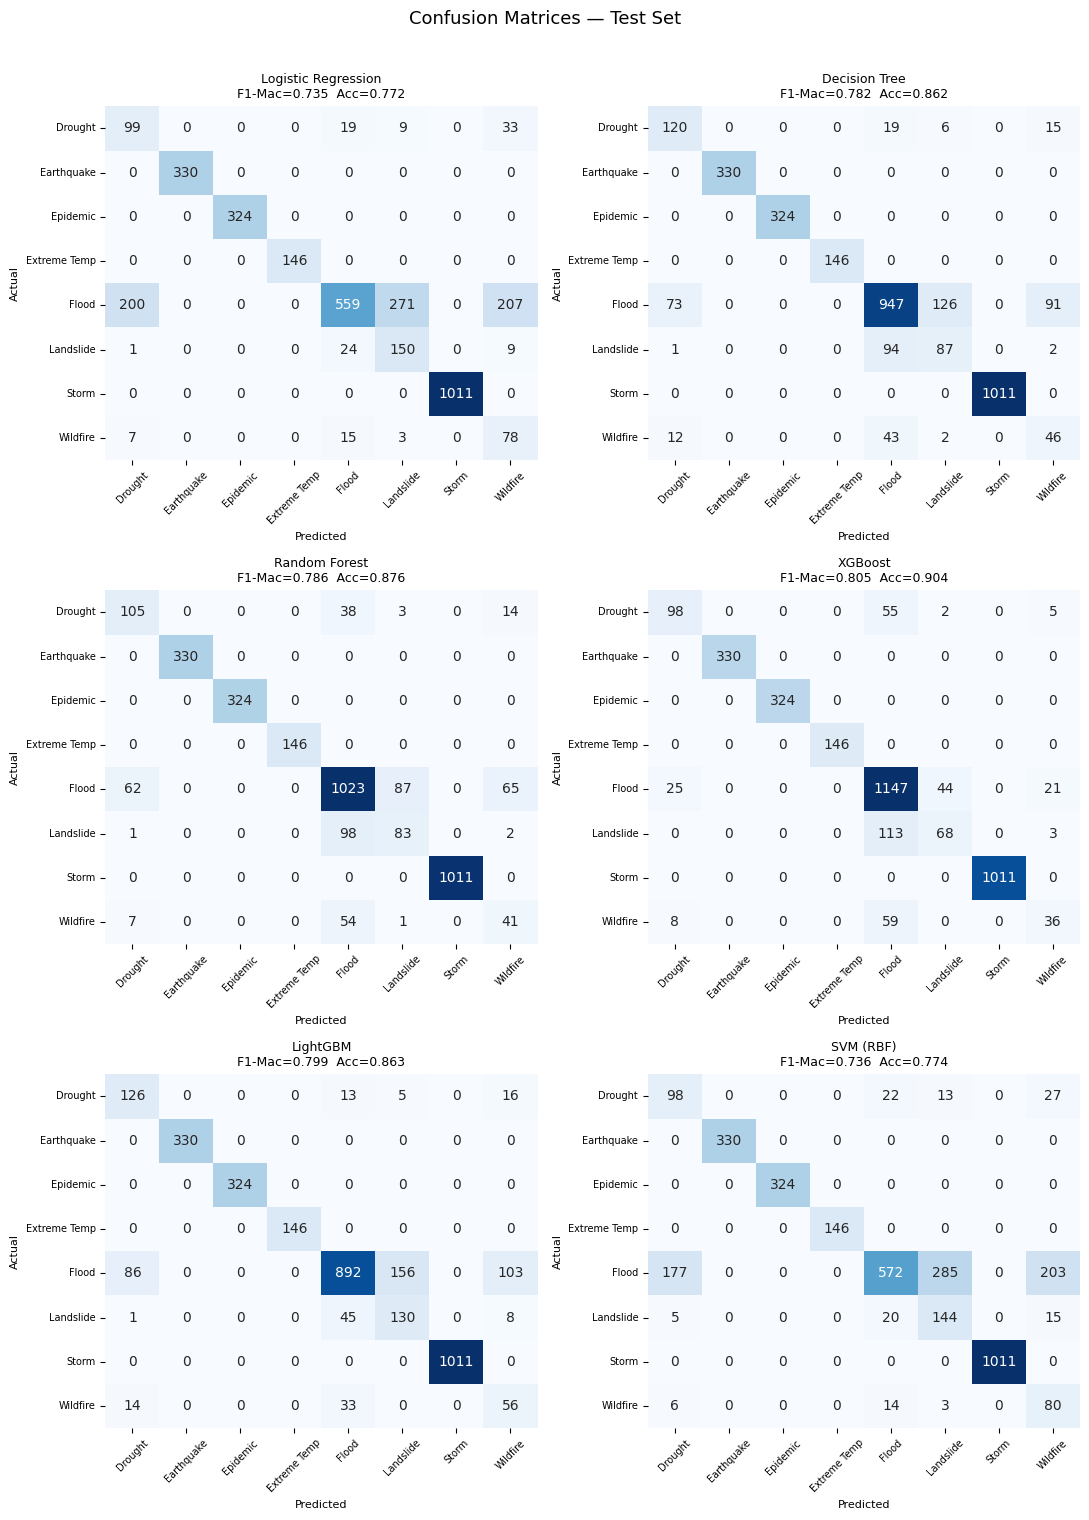

In [ ]:
n_models = len(models)              # 9 models → 3×3 grid
ncols    = 2
nrows    = (n_models + ncols - 1) // ncols   # auto-compute rows

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5.5, nrows * 5))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax,
                xticklabels=TARGET_NAMES, yticklabels=TARGET_NAMES,
                cmap="Blues", cbar=False)
    f1  = f1_score(y_test, y_pred, average="macro")
    acc = accuracy_score(y_test, y_pred)
    ax.set_title(f"{name}\nF1-Mac={f1:.3f}  Acc={acc:.3f}", fontsize=9)
    ax.set_xlabel("Predicted", fontsize=8)
    ax.set_ylabel("Actual", fontsize=8)
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0,  labelsize=7)

# Hide unused subplots
for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle("Confusion Matrices — Test Set", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

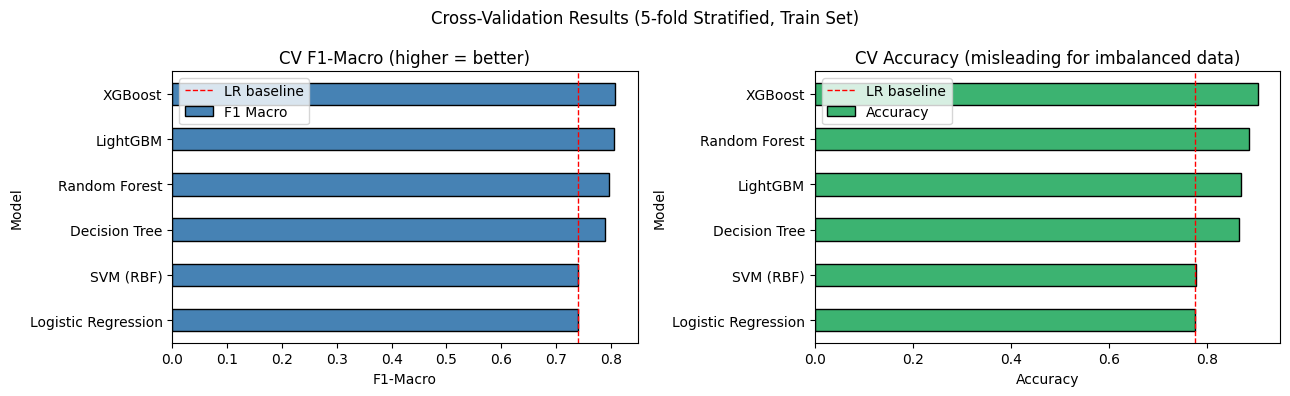

In [ ]:
# Visual comparison — CV F1-Macro vs Accuracy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cv_df["F1 Macro"].sort_values().plot(
    kind="barh", ax=axes[0], color="steelblue", edgecolor="black"
)
axes[0].set_title("CV F1-Macro (higher = better)")
axes[0].set_xlabel("F1-Macro")
axes[0].axvline(cv_df.loc["Logistic Regression", "F1 Macro"], color="red",
                linestyle="--", linewidth=1, label="LR baseline")
axes[0].legend()

cv_df["Accuracy"].sort_values().plot(
    kind="barh", ax=axes[1], color="mediumseagreen", edgecolor="black"
)
axes[1].set_title("CV Accuracy (misleading for imbalanced data)")
axes[1].set_xlabel("Accuracy")
axes[1].axvline(cv_df.loc["Logistic Regression", "Accuracy"], color="red",
                linestyle="--", linewidth=1, label="LR baseline")
axes[1].legend()

plt.suptitle("Cross-Validation Results (5-fold Stratified, Train Set)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Per-class classification report for every model
for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

  Logistic Regression
              precision    recall  f1-score   support

     Drought       0.32      0.62      0.42       160
  Earthquake       1.00      1.00      1.00       330
    Epidemic       1.00      1.00      1.00       324
Extreme Temp       1.00      1.00      1.00       146
       Flood       0.91      0.45      0.60      1237
   Landslide       0.35      0.82      0.49       184
       Storm       1.00      1.00      1.00      1011
    Wildfire       0.24      0.76      0.36       103

    accuracy                           0.77      3495
   macro avg       0.73      0.83      0.73      3495
weighted avg       0.88      0.77      0.79      3495

  Decision Tree
              precision    recall  f1-score   support

     Drought       0.58      0.75      0.66       160
  Earthquake       1.00      1.00      1.00       330
    Epidemic       1.00      1.00      1.00       324
Extreme Temp       1.00      1.00      1.00       146
       Flood       0.86      0.77      0

In [ ]:
from imblearn.over_sampling    import RandomOverSampler, SMOTE, ADASYN
from imblearn.under_sampling   import RandomUnderSampler, TomekLinks
from imblearn.combine          import SMOTETomek

imbalance_methods = {
    "Original Data"          : None,
    "Random Over-sampling"   : RandomOverSampler(random_state=42),
    "Random Under-sampling"  : RandomUnderSampler(random_state=42),
    "SMOTE"                  : SMOTE(random_state=42),
    "ADASYN"                 : ADASYN(random_state=42),
    "Tomek Links"            : TomekLinks(n_jobs=-1),
    "SMOTE-Tomek"            : SMOTETomek(random_state=42, n_jobs=-1)
}

def get_models():
    return {
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
        "SVM"                : SVC(random_state=42), # SVM No support n_jobs for fit
        "Decision Tree"      : DecisionTreeClassifier(random_state=42),
        "Random Forest"      : RandomForestClassifier(random_state=42, n_jobs=-1),
        "XGBoost"            : XGBClassifier(random_state=42, n_jobs=-1),
        "LightGBM"           : LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1) # verbose=-1  for close annoying logs
    }

master_summary = []

for method_name, sampler in imbalance_methods.items():
    print(f"processing Method: {method_name}...")
    
    if sampler is not None:
        X_train_res, y_train_res = sampler.fit_resample(X_train, y_train)
    else:
        X_train_res, y_train_res = X_train, y_train
        
    current_models = get_models()
    for model_name, model in current_models.items():
        try:
            model.fit(X_train_res, y_train_res)
            y_pred = model.predict(X_test)
            
            
            master_summary.append({
                "Imbalance Method": method_name,
                "Model"           : model_name,
                "Accuracy"        : accuracy_score(y_test, y_pred),
                "F1 Macro"        : f1_score(y_test, y_pred, average="macro"),
                "F1 Weighted"     : f1_score(y_test, y_pred, average="weighted"),
                "Precision"       : precision_score(y_test, y_pred, average="macro", zero_division=0),
                "Recall"          : recall_score(y_test, y_pred, average="macro", zero_division=0)
            })
        except Exception as e:
            print(f"เกิดข้อผิดพลาดกับ {model_name} ในวิธี {method_name}: {e}")

master_df = pd.DataFrame(master_summary)

master_df = master_df.set_index(["Imbalance Method", "Model"])
master_df_sorted = master_df.sort_values("F1 Macro", ascending=False).round(4)

master_df_sorted

processing Method: Original Data...
processing Method: Random Over-sampling...
processing Method: Random Under-sampling...
processing Method: SMOTE...
processing Method: ADASYN...
processing Method: Tomek Links...
processing Method: SMOTE-Tomek...


Accuracy  F1 Macro  F1 Weighted  \
Imbalance Method      Model                                                  
Tomek Links           XGBoost                0.9096    0.8144       0.9019   
                      LightGBM               0.9076    0.8143       0.9014   
SMOTE-Tomek           LightGBM               0.8753    0.8103       0.8828   
SMOTE                 LightGBM               0.8773    0.8103       0.8847   
Original Data         LightGBM               0.9062    0.8090       0.8980   
SMOTE                 XGBoost                0.8609    0.8052       0.8717   
SMOTE-Tomek           XGBoost                0.8607    0.8047       0.8715   
ADASYN                LightGBM               0.8692    0.8021       0.8773   
Tomek Links           Random Forest          0.8953    0.8004       0.8907   
Random Over-sampling  XGBoost                0.8504    0.8004       0.8627   
Original Data         Random Forest          0.8941    0.7992       0.8894   
Random Over-sampling  LightGBM               0.8541    0.7971       0.8667   
Original Data         XGBoost                0.9056    0.7970       0.8947   
                      Decision Tree          0.8867    0.7951       0.8844   
Tomek Links           Decision Tree          0.8867    0.7937       0.8849   
ADASYN                XGBoost                0.8509    0.7925       0.8631   
SMOTE-Tomek           Random Forest          0.8564    0.7846       0.8657   
Random Over-sampling  Decision Tree          0.8615    0.7826       0.8681   
                      Random Forest          0.8667    0.7823       0.8719   
ADASYN                Decision Tree          0.8552    0.7797       0.8633   
SMOTE                 Random Forest          0.8555    0.7797       0.8634   
                      Decision Tree          0.8607    0.7796       0.8676   
ADASYN                Random Forest          0.8529    0.7794       0.8618   
SMOTE-Tomek           Decision Tree          0.8564    0.7791       0.8648   
Random Under-sampling XGBoost                0.8169    0.7780       0.8326   
                      LightGBM               0.8143    0.7693       0.8320   
                      Random Forest          0.8126    0.7678       0.8293   
                      Decision Tree          0.8006    0.7607       0.8201   
SMOTE-Tomek           SVM                    0.8149    0.7607       0.8298   
SMOTE                 SVM                    0.8146    0.7605       0.8295   
                      Logistic Regression    0.8052    0.7553       0.8209   
Random Over-sampling  SVM                    0.7957    0.7545       0.8114   
SMOTE-Tomek           Logistic Regression    0.8026    0.7536       0.8182   
ADASYN                SVM                    0.7997    0.7525       0.8152   
                      Logistic Regression    0.7871    0.7415       0.8035   
Random Over-sampling  Logistic Regression    0.7768    0.7387       0.7926   
Tomek Links           Logistic Regression    0.8890    0.7325       0.8657   
Original Data         Logistic Regression    0.8887    0.7308       0.8655   
Random Under-sampling Logistic Regression    0.7516    0.7210       0.7658   
                      SVM                    0.7265    0.6974       0.7417   
Tomek Links           SVM                    0.8864    0.6879       0.8505   
Original Data         SVM                    0.8858    0.6783       0.8483   

                                           Precision  Recall  
Imbalance Method      Model                                   
Tomek Links           XGBoost                 0.8595  0.7878  
                      LightGBM                0.8457  0.7940  
SMOTE-Tomek           LightGBM                0.7876  0.8506  
SMOTE                 LightGBM                0.7886  0.8472  
Original Data         LightGBM                0.8540  0.7832  
SMOTE                 XGBoost                 0.7801  0.8640  
SMOTE-Tomek           XGBoost                 0.7795  0.8639  
ADASYN                LightGBM             

## 11. Confusion Matrices

## 12. Feature Importance (Tree-Based Models)

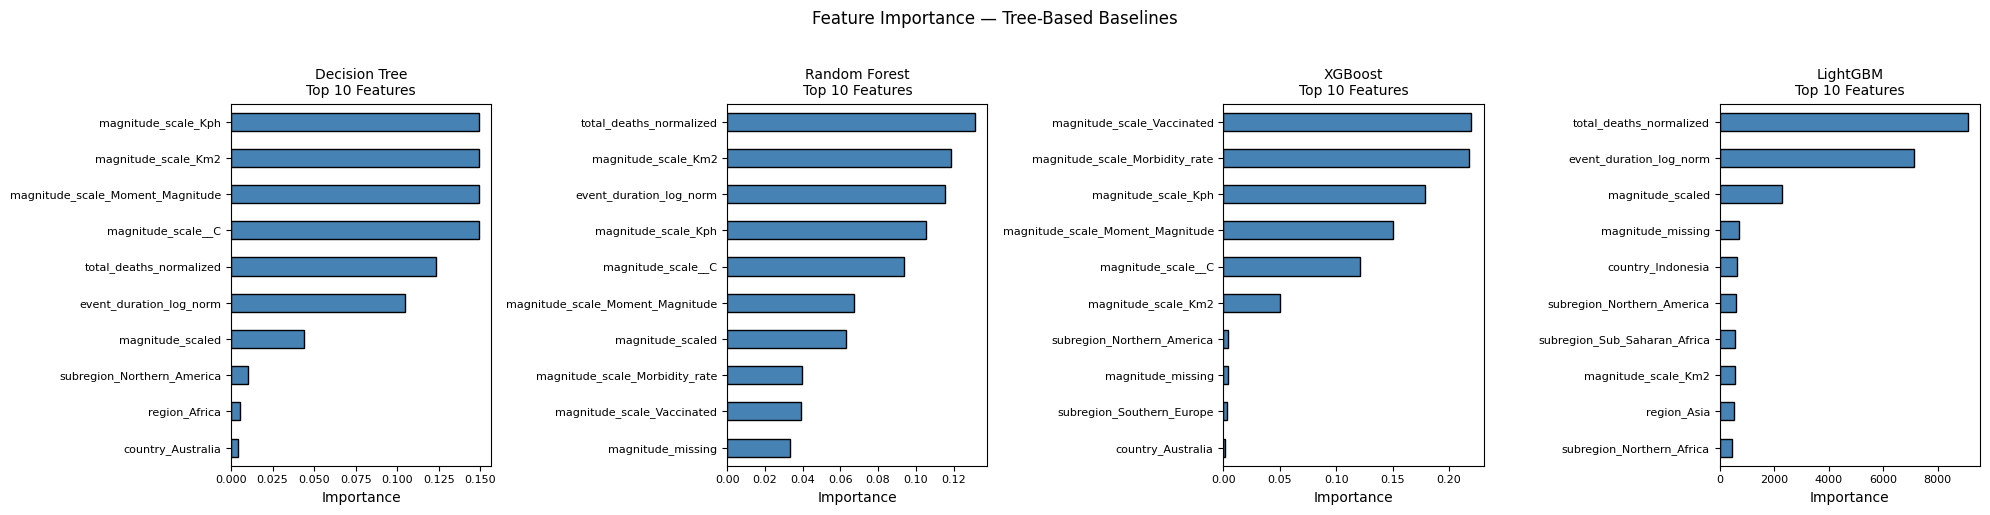

In [ ]:
tree_models = {
    "Decision Tree": models["Decision Tree"],
    "Random Forest": models["Random Forest"],
    "XGBoost"      : models["XGBoost"],
    "LightGBM" :models["LightGBM"]
}

fig, axes = plt.subplots(1, len(tree_models), figsize=(20, 5))

for ax, (name, model) in zip(axes, tree_models.items()):
    imp = pd.Series(model.feature_importances_, index=X.columns)
    imp.nlargest(10).sort_values().plot(
        kind="barh", ax=ax, color="steelblue", edgecolor="black"
    )
    ax.set_title(f"{name}\nTop 10 Features", fontsize=10)
    ax.set_xlabel("Importance")
    ax.tick_params(labelsize=8)

plt.suptitle("Feature Importance — Tree-Based Baselines", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 13. Comparison 

In [ ]:
print("CV vs Test F1-Macro comparison:")
print(f"{'Model':<22}  {'CV F1-Mac':>10}  {'Test F1-Mac':>11}")
print("-" * 48)
for name in models:
    cv_f1  = cv_df.loc[name, "F1 Macro"]
    tst_f1 = test_df.loc[name, "F1 Macro"]
    gap    = tst_f1 - cv_f1
    flag   = " overfit" if gap < -0.05 else ""
    print(f"{name:<22}  {cv_f1:>10.4f}  {tst_f1:>11.4f}{flag}")

print("\nBest model by Test F1-Macro:")
best = test_df["F1 Macro"].idxmax()
print(f"{best}  (F1-Macro = {test_df.loc[best, 'F1 Macro']:.4f})")

CV vs Test F1-Macro comparison:
Model                    CV F1-Mac  Test F1-Mac
------------------------------------------------
Logistic Regression         0.7400       0.7345
Decision Tree               0.7885       0.7816
Random Forest               0.7971       0.7863
XGBoost                     0.8080       0.8046
LightGBM                    0.8049       0.7992
SVM (RBF)                   0.7401       0.7356

Best model by Test F1-Macro:
XGBoost  (F1-Macro = 0.8046)


In [ ]:
X_train.to_csv('../data/cleaned/X_train_clean.csv', index=False)
X_test.to_csv('../data/cleaned/X_test_clean.csv', index=False)
y_train.to_csv('../data/cleaned/y_train_clean.csv', index=False)
y_test.to_csv('../data/cleaned/y_test_clean.csv', index=False)

print('Save!')

Save!
